> Alzheimer's Disease Multiclass Images Dataset  
https://www.kaggle.com/datasets/aryansinghal10/alzheimers-multiclass-dataset-equal-and-augmented

In [1]:
import matplotlib.pyplot as plt
import numpy as np

In [2]:
import tensorflow as tf
from tensorflow.keras import mixed_precision

gpus = tf.config.list_physical_devices('GPU')
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)

tf.config.optimizer.set_jit(True)
mixed_precision.set_global_policy('mixed_float16')

print("Num GPUs Available:", len(gpus))
print("Mixed Precision Policy:", mixed_precision.global_policy())

I0000 00:00:1776074468.763737   10401 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1776074469.707951   10401 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1776074486.620442   10401 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Num GPUs Available: 1
Mixed Precision Policy: <DTypePolicy "mixed_float16">


In [3]:
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Sequential, Model

In [4]:
BATCH_SIZE = 16
IMAGE_SIZE = (224, 224)

train_dataset = tf.keras.utils.image_dataset_from_directory(
    'datasets/alzheimer/train',
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical'
 )

test_dataset = tf.keras.utils.image_dataset_from_directory(
    'datasets/alzheimer/test',
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical',
    shuffle=True
)

Found 10240 files belonging to 4 classes.


I0000 00:00:1776074501.284125   10401 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5560 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


Found 1279 files belonging to 4 classes.


In [5]:
def normalize(x, y):
    return tf.cast(x, tf.float32) / 255.0, y

AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.map(normalize, num_parallel_calls=AUTOTUNE).shuffle(256).prefetch(1)
test_dataset = test_dataset.map(normalize, num_parallel_calls=AUTOTUNE).prefetch(1)

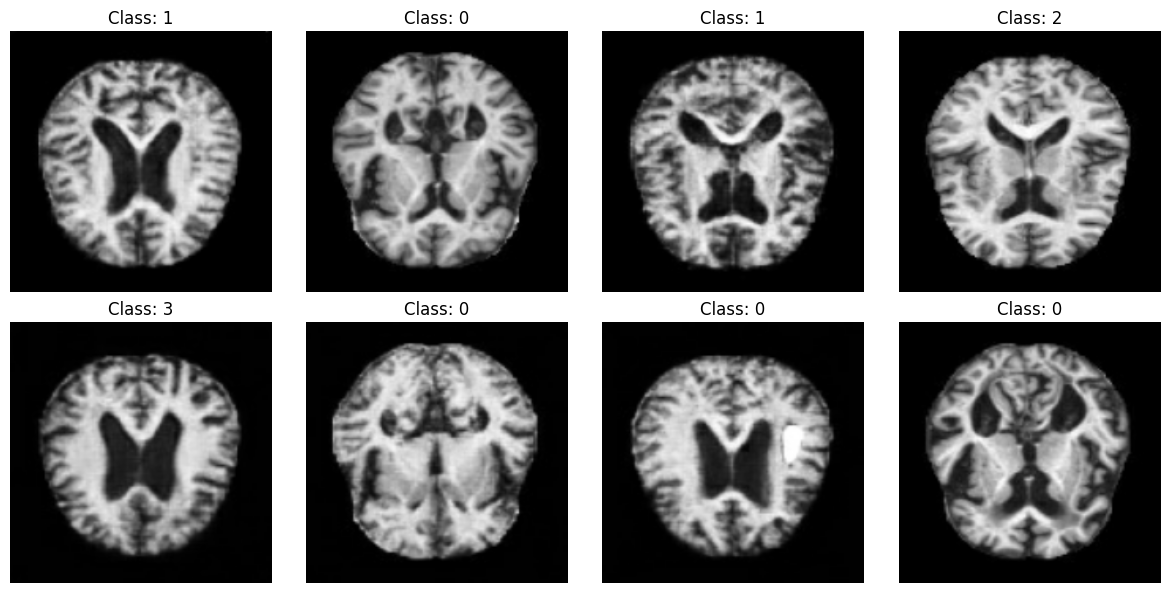

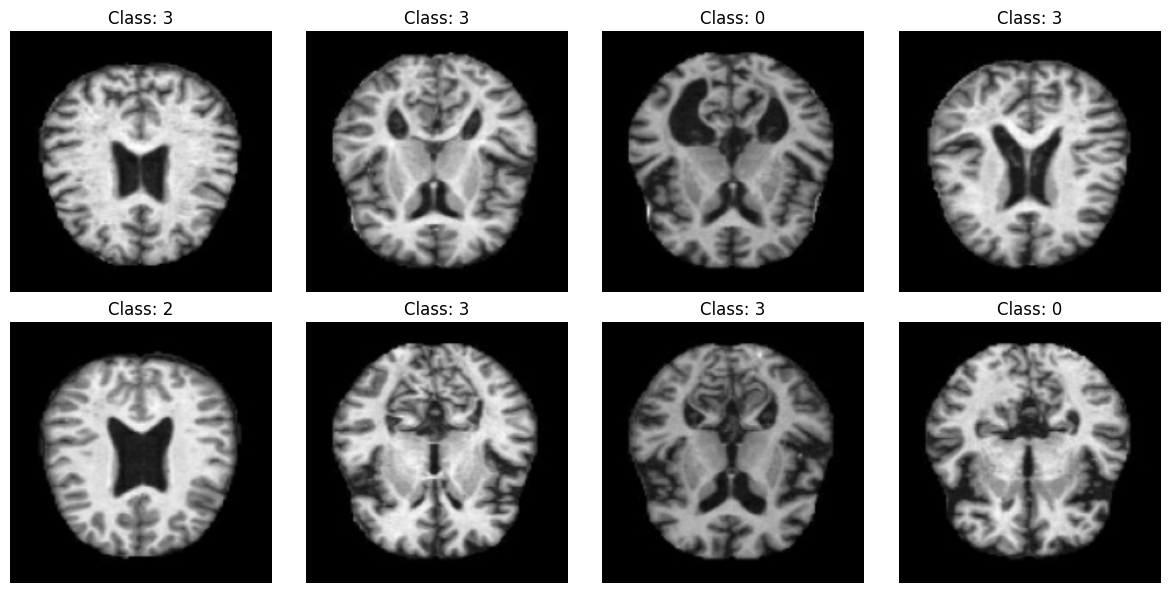

In [6]:
import math

def plot_images(images, labels):
    num_images = images.shape[0]
    num_rows = int(math.ceil(num_images / 4))
    fig, axes = plt.subplots(num_rows, 4, figsize=(12, 3 * num_rows))
    if num_rows == 1:
        axes = np.expand_dims(axes, axis=0)
    for i in range(num_images):
        row = i // 4
        col = i % 4
        axes[row, col].imshow(images[i])
        axes[row, col].set_title(f"Class: {np.argmax(labels[i])}")
        axes[row, col].axis('off')
    for i in range(num_images, num_rows * 4):
        row = i // 4
        col = i % 4
        axes[row, col].axis('off')
    plt.tight_layout()
    plt.show()

for images, labels in train_dataset.take(1):
    plot_images(images.numpy()[:8], labels.numpy()[:8])

for images, labels in test_dataset.take(1):
    plot_images(images.numpy()[:8], labels.numpy()[:8])

In [7]:
# model = Sequential([
#     Conv2D(64, (3, 3), activation='relu', padding='same', input_shape=(224, 224, 3)),
#     Conv2D(64, (3, 3), activation='relu', padding='same'),
#     MaxPooling2D((2, 2), strides=2),

#     Conv2D(128, (3, 3), activation='relu', padding='same'),
#     Conv2D(128, (3, 3), activation='relu', padding='same'),
#     MaxPooling2D((2, 2), strides=2),

#     Conv2D(256, (3, 3), activation='relu', padding='same'),
#     Conv2D(256, (3, 3), activation='relu', padding='same'),
#     Conv2D(256, (3, 3), activation='relu', padding='same'),
#     Conv2D(256, (3, 3), activation='relu', padding='same'),
#     MaxPooling2D((2, 2), strides=2),

#     Conv2D(512, (3, 3), activation='relu', padding='same'),
#     Conv2D(512, (3, 3), activation='relu', padding='same'),
#     Conv2D(512, (3, 3), activation='relu', padding='same'),
#     Conv2D(512, (3, 3), activation='relu', padding='same'),
#     MaxPooling2D((2, 2), strides=2),

#     Conv2D(512, (3, 3), activation='relu', padding='same'),
#     Conv2D(512, (3, 3), activation='relu', padding='same'),
#     Conv2D(512, (3, 3), activation='relu', padding='same'),
#     Conv2D(512, (3, 3), activation='relu', padding='same'),
#     MaxPooling2D((2, 2), strides=2),

#     Flatten(),
#     Dense(4096, activation='relu'),
#     Dense(4096, activation='relu'),
#     Dense(4, activation='softmax')
# ])

In [8]:
# model.compile(optimizer=Adam(1e-4), loss='categorical_crossentropy', metrics=['accuracy'])

In [9]:
# history = model.fit(train_dataset, epochs=25, validation_data=test_dataset, verbose=1)

In [10]:
from tensorflow.keras.applications import VGG16

base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
for layer in base_model.layers:
    layer.trainable = False

num_classes = 4
x = Flatten()(base_model.output)
predictions = Dense(num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4)              │       100,356 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,815,044 (56.51 MB)

 Trainable params: 100,356 (392.02 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [11]:
model.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])

In [12]:
history = model.fit(train_dataset, epochs=25, validation_data=test_dataset, verbose=1)

Epoch 1/25


I0000 00:00:1776074515.679385   10602 service.cc:153] XLA service 0x75490c0352c0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1776074515.679431   10602 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 4060 Laptop GPU, Compute Capability 8.9 (Driver: 13.1.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.20.0)
I0000 00:00:1776074515.806945   10602 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1776074516.135133   10602 cuda_dnn.cc:461] Loaded cuDNN version 92000
I0000 00:00:1776074516.159202   10602 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_2049__.74
I0000 00:00:1776074524.938974   10602 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


640/640 ━━━━━━━━━━━━━━━━━━━━ 39s 42ms/step - accuracy: 0.7616 - loss: 0.5936 - val_accuracy: 0.7068 - val_loss: 0.6361
Epoch 2/25
640/640 ━━━━━━━━━━━━━━━━━━━━ 24s 35ms/step - accuracy: 0.8679 - loss: 0.3255 - val_accuracy: 0.6927 - val_loss: 0.7947
Epoch 3/25
640/640 ━━━━━━━━━━━━━━━━━━━━ 26s 37ms/step - accuracy: 0.9119 - loss: 0.2237 - val_accuracy: 0.7592 - val_loss: 0.5525
Epoch 4/25
640/640 ━━━━━━━━━━━━━━━━━━━━ 24s 35ms/step - accuracy: 0.9365 - loss: 0.1675 - val_accuracy: 0.8288 - val_loss: 0.4036
Epoch 5/25
640/640 ━━━━━━━━━━━━━━━━━━━━ 25s 35ms/step - accuracy: 0.9330 - loss: 0.1664 - val_accuracy: 0.7998 - val_loss: 0.4801
Epoch 6/25
640/640 ━━━━━━━━━━━━━━━━━━━━ 25s 35ms/step - accuracy: 0.9571 - loss: 0.1206 - val_accuracy: 0.8937 - val_loss: 0.2535
Epoch 7/25
640/640 ━━━━━━━━━━━━━━━━━━━━ 25s 37ms/step - accuracy: 0.9727 - loss: 0.0870 - val_accuracy: 0.9187 - val_loss: 0.2198
Epoch 8/25
640/640 ━━━━━━━━━━━━━━━━━━━━ 24s 36ms/step - accuracy: 0.9618 - loss: 0.1044 - val_accurac

In [17]:
model.save('outputs/vgg16-alzheimer-model-98_91.h5')

In [18]:
model.save('outputs/vgg16-alzheimer-model-98_91.keras')